In [36]:
#import labraries

#data mainipulation
import pandas as pd
import numpy as np
#plotting
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm.notebook as tqdm
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
import random
#machine learning
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from keras.preprocessing.image import load_img,img_to_array
from keras.models import Sequential
from keras.layers import Dense,Dropout,Conv2D,Flatten,MaxPooling2D
from tensorflow.keras.layers import BatchNormalization, GlobalAveragePooling2D
#file handling
import os



In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# List the emotions folder contents
emotions_path = "/content/drive/My Drive/emotions_balanced/"
print("Contents of emotions folder:")
print(os.listdir(emotions_path))

# List train folder contents
train_path = "/content/drive/My Drive/emotions_balanced/train/"
print("\nContents of train folder:")
print(os.listdir(train_path))

# List test folder contents
test_path = "/content/drive/My Drive/emotions_balanced/test/"
print("\nContents of test folder:")
print(os.listdir(test_path))

ModuleNotFoundError: No module named 'google.colab'

In [13]:
#loading dataset
TRAIN_DIR="C:/Users/ش/Desktop/img project/emotions_balanced/train"
TEST_DIR="C:/Users/ش/Desktop/img project/emotions_balanced/test"

In [14]:
#convert folders into coplete image path and conresponding labels
#basically converting the folder emotions into a csv format
def load_data(directory):
    image_paths = []
    labels = []
    for label in os.listdir(directory):
        label_dir = os.path.join(directory, label)          
        if not os.path.isdir(label_dir):
            continue
        for filename in os.listdir(label_dir):
            image_path = os.path.join(label_dir, filename)
            image_paths.append(image_path)
            labels.append(label)
    return image_paths, labels

In [15]:
#initiaize the Dataframe
train=pd.DataFrame()
train['image'],train['label']=load_data(TRAIN_DIR)
#suffle the dataset
train=train.sample(frac=1).reset_index(drop=True)
train.head()



,image,label
0,C:/Users/ش/Desktop/img project/emotions_balanc...,neutral
1,C:/Users/ش/Desktop/img project/emotions_balanc...,neutral
2,C:/Users/ش/Desktop/img project/emotions_balanc...,fear
3,C:/Users/ش/Desktop/img project/emotions_balanc...,neutral
4,C:/Users/ش/Desktop/img project/emotions_balanc...,sad


In [16]:
#initiaize the Dataframe
test=pd.DataFrame()
test['image'],test['label']=load_data(TEST_DIR)

train.head()

,image,label
0,C:/Users/ش/Desktop/img project/emotions_balanc...,neutral
1,C:/Users/ش/Desktop/img project/emotions_balanc...,neutral
2,C:/Users/ش/Desktop/img project/emotions_balanc...,fear
3,C:/Users/ش/Desktop/img project/emotions_balanc...,neutral
4,C:/Users/ش/Desktop/img project/emotions_balanc...,sad


<Axes: xlabel='count', ylabel='label'>

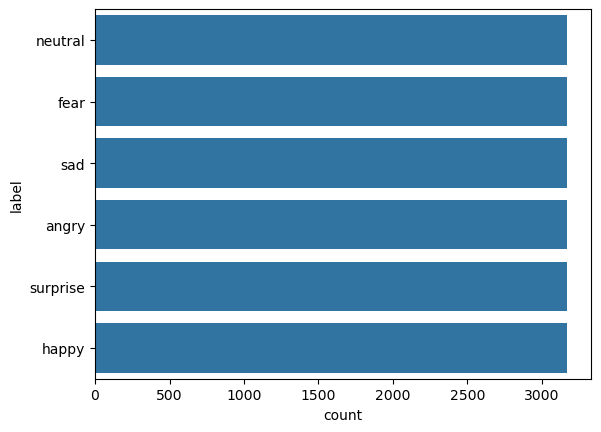

In [17]:
#EDA
sns.countplot(train['label'])


we notice that they are they are not equally distriputed we need to deal with that later

<PIL.JpegImagePlugin.JpegImageFile image mode=L size=48x48 at 0x15F747A9400>


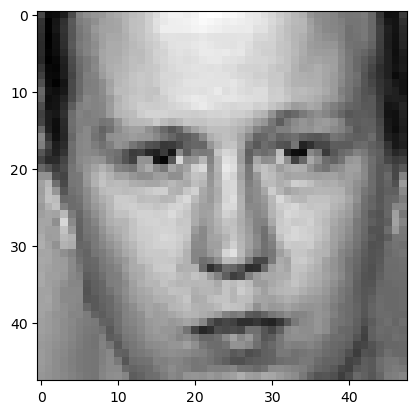

In [18]:
# show the image
from PIL import Image
img=Image.open(train['image'][0])
print(img)
plt.imshow(img,cmap="gray")

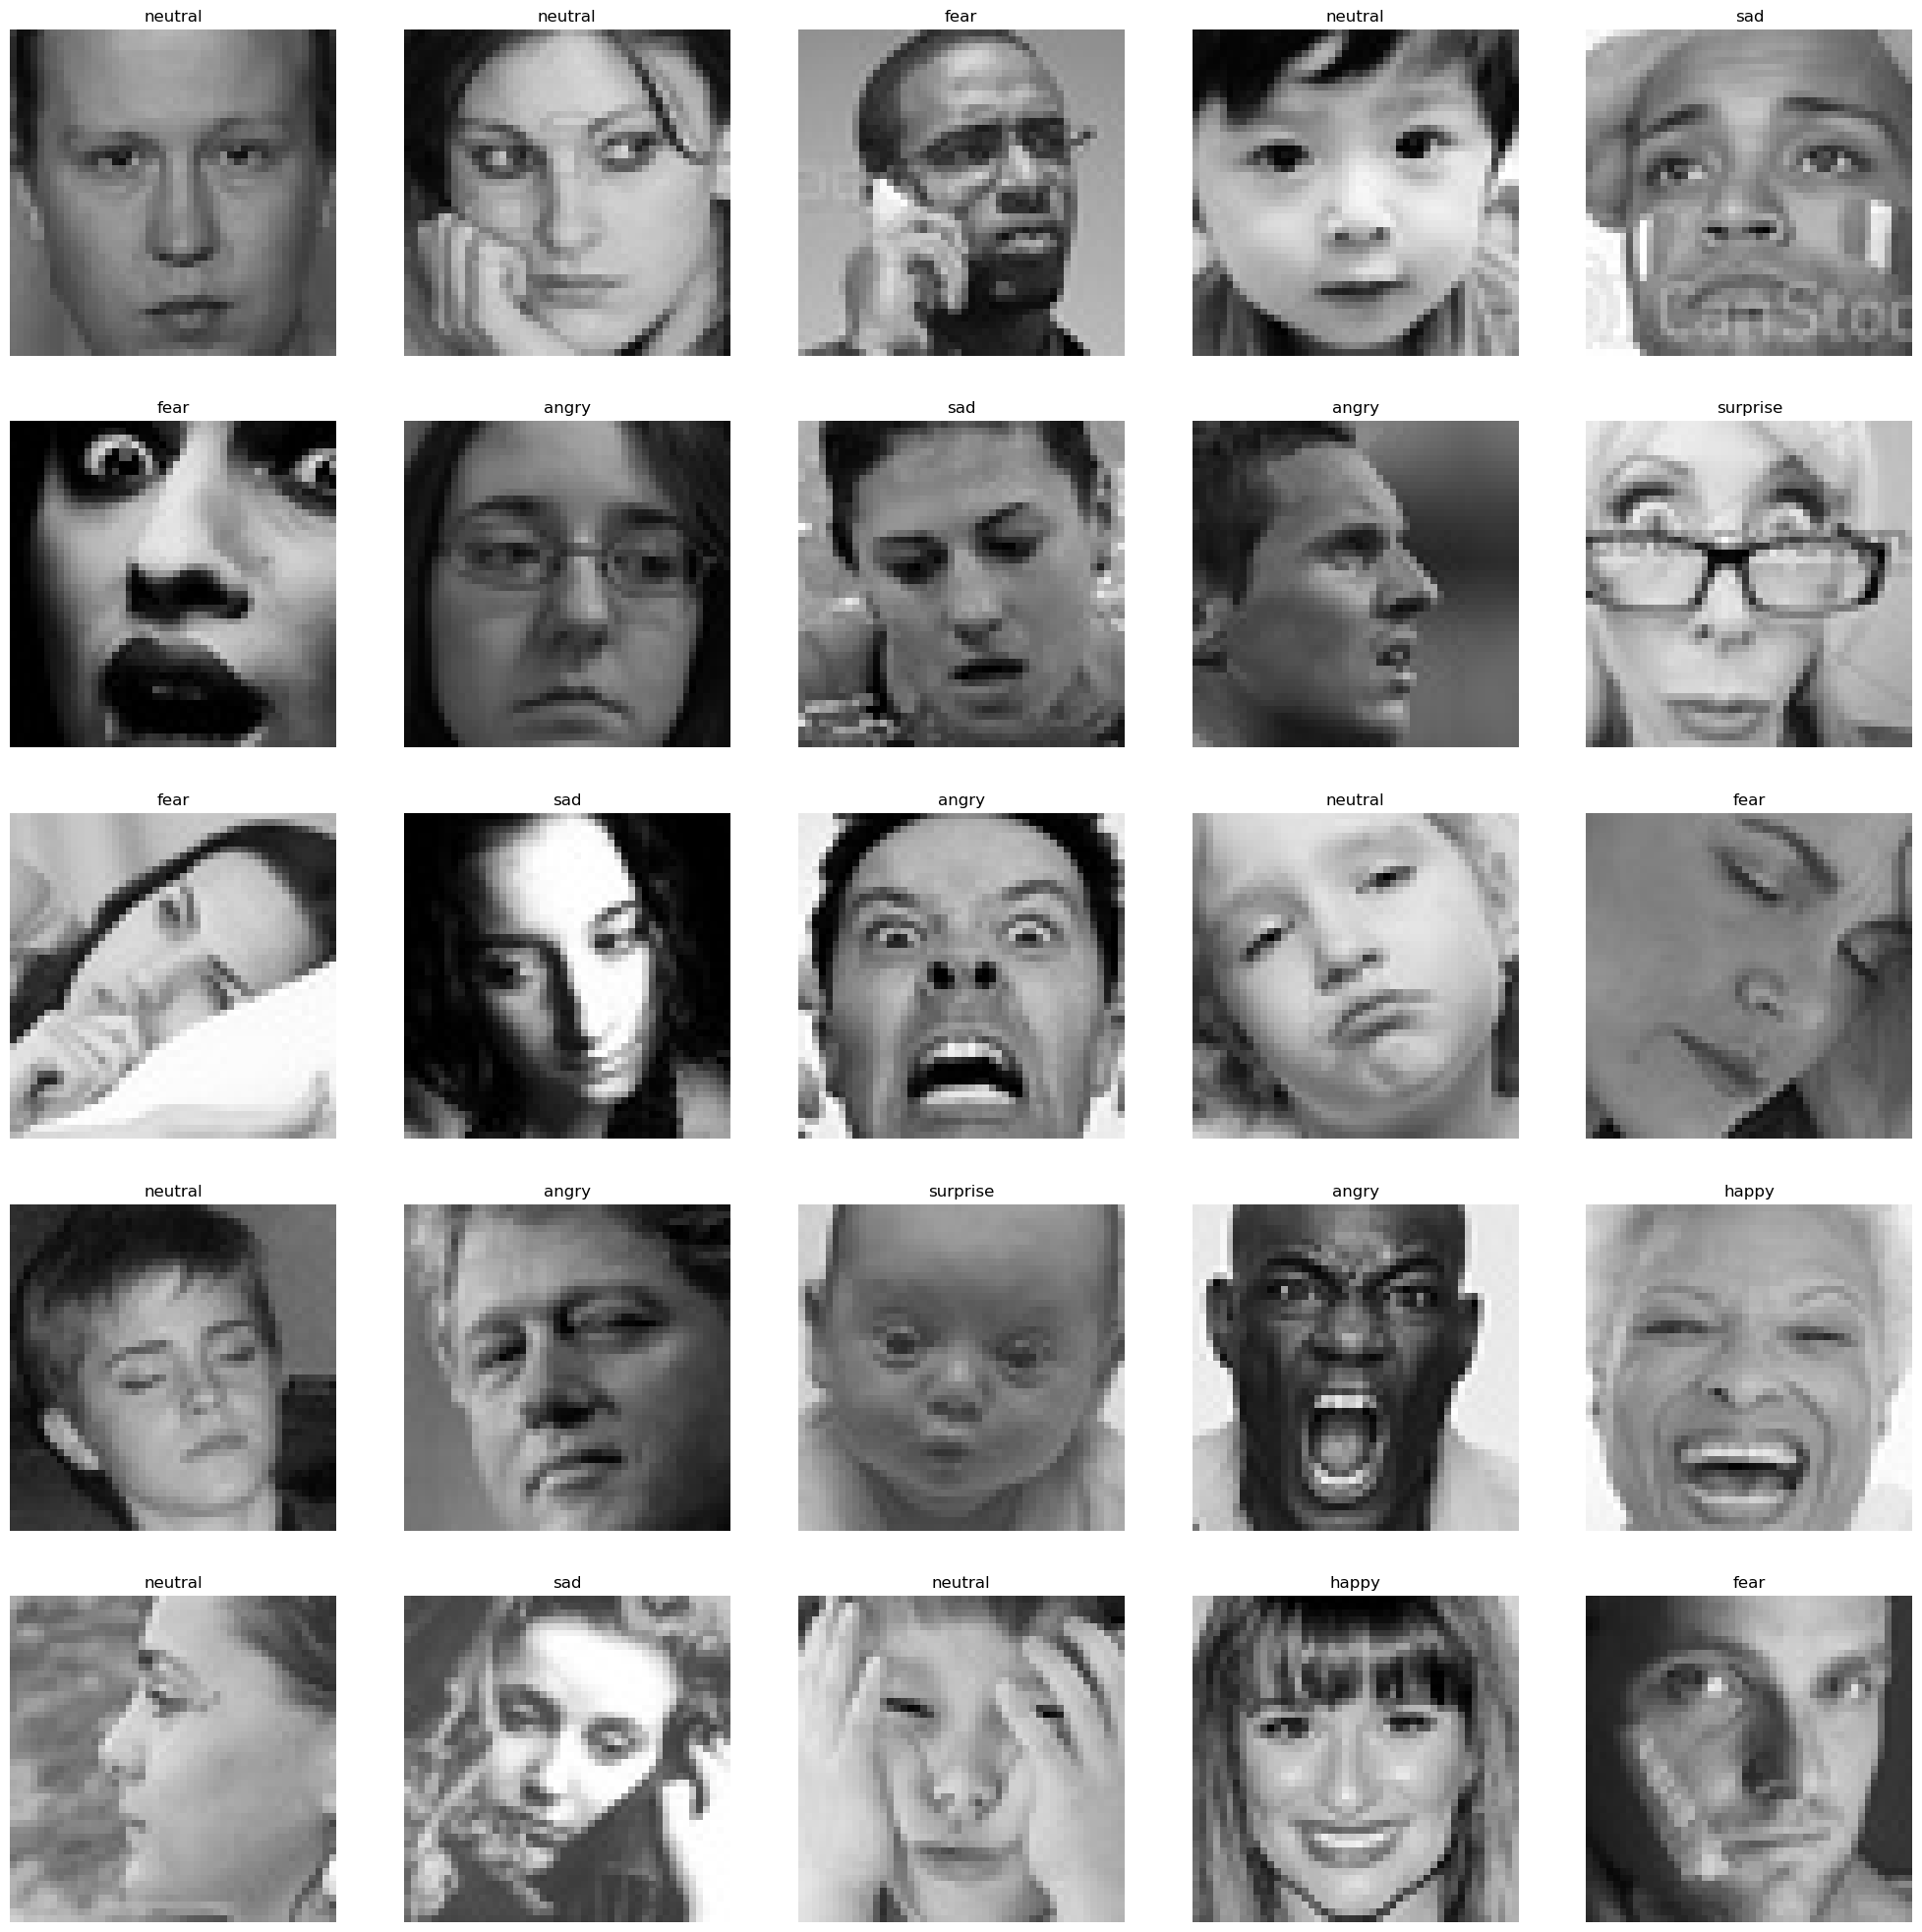

In [19]:
from keras.src.utils.image_utils import load_img
#grid of images
files=train.iloc[0:25]
plt.figure(figsize=(25,25))
for index,file ,label in files.itertuples():
  plt.subplot(5,5,index+1)
  img=load_img(file)
  img=np.array(img)
  plt.imshow(img)
  plt.title(label)
  plt.axis("off")


##feature extraction

In [20]:
def feature_extraction(images):
  features=[]
  for image in tqdm.tqdm(images):
    img=load_img(image,color_mode='grayscale')
    img=np.array(img)
    features.append(img)
  features=np.array(features)
  features=features.reshape(len(features),48,48,1)
  return features

In [21]:
train_features=feature_extraction(train['image'])



  0%|          | 0/19026 [00:00<?, ?it/s]

In [22]:
test_features=feature_extraction(test['image'])

  0%|          | 0/4986 [00:00<?, ?it/s]

In [23]:
#normalize
x_train=train_features/255.0
x_test=test_features/255.0

In [24]:
#covert label to intger
#this can be converted to 1-hot ecoding for better preformace
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
le.fit(train['label'])
y_train=le.transform(train['label'])
y_test=le.transform(test['label'])


In [25]:
#1 hot encoding
y_train=to_categorical(y_train,num_classes=6)
y_test=to_categorical(y_test,num_classes=6)

In [26]:
y_train[0]#this will show the first catagory in 0,1

array([0., 0., 0., 1., 0., 0.])

In [27]:
input_shape=(48,48,1)
output =6

##making the model CNN

In [43]:
# POOR RESULT 
#model=Sequential()
# #convanotinal layers
# model.add(Conv2D(128,kernel_size=(3,3),activation='relu',input_shape=input_shape, padding='same'))#first layer
# model.add(MaxPooling2D(pool_size=(3,3)))#second
# model.add(Dropout(0.4))#third

# model.add(Conv2D(256,kernel_size=(3,3),activation='relu', padding='same'))#first layer
# model.add(MaxPooling2D(pool_size=(3,3)))#second
# model.add(Dropout(0.4))#third

# model.add(Conv2D(512,kernel_size=(3,3),activation='relu', padding='same'))#first layer
# model.add(MaxPooling2D(pool_size=(3,3)))#second
# model.add(Dropout(0.4))#third

# model.add(Conv2D(512,kernel_size=(3,3),activation='relu', padding='same'))#first layer
# model.add(MaxPooling2D(pool_size=(3,3)))#second
# model.add(Dropout(0.4))#third

# model.add(Flatten())
# #now fully connected

# model.add(Dense(512,activation='relu'))
# model.add(Dropout(0.4))
# model.add(Dense(512,activation='relu'))
# model.add(Dropout(0.3))

# #output layers
# model.add(Dense(output,activation='softmax'))




In [48]:
model = Sequential([
    Conv2D(64, (3,3), activation='relu', padding='same', input_shape=input_shape),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),
    
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),
    
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.3),
    
    Conv2D(512, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.3),
    
    GlobalAveragePooling2D(),  # better than Flatten + Dense 512
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

In [49]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [50]:
#just to know what this fuction does
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_23 (Conv2D)                   │ (None, 48, 48, 64)          │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 48, 48, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_19 (MaxPooling2D)      │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_23 (Dropout)                 │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_24 (Conv2D)                   │ (None, 24, 24, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 24, 24, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_20 (MaxPooling2D)      │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_24 (Dropout)                 │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_25 (Conv2D)                   │ (None, 12, 12, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 12, 12, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_21 (MaxPooling2D)      │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_25 (Dropout)                 │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_26 (Conv2D)                   │ (None, 6, 6, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 6, 6, 512)           │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_22 (MaxPooling2D)      │ (None, 3, 3, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_26 (Dropout)                 │ (None, 3, 3, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_27 (Dropout)                 │ (None, 256)                 │              

 Total params: 1,686,534 (6.43 MB)

 Trainable params: 1,684,614 (6.43 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [51]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=1)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.1669 - loss: 1.7922
Test accuracy: 0.1669
Test loss: 1.7922


In [52]:
history=model.fit(x_train,y_train,batch_size=128,epochs=100,validation_data=(x_test,y_test))




Epoch 1/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 73s 475ms/step - accuracy: 0.2319 - loss: 1.8340 - val_accuracy: 0.1663 - val_loss: 2.2644
Epoch 2/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 68s 460ms/step - accuracy: 0.3411 - loss: 1.5956 - val_accuracy: 0.1667 - val_loss: 2.1589
Epoch 3/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 68s 456ms/step - accuracy: 0.4062 - loss: 1.4547 - val_accuracy: 0.3343 - val_loss: 1.6585
Epoch 4/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 69s 464ms/step - accuracy: 0.4512 - loss: 1.3754 - val_accuracy: 0.3628 - val_loss: 1.5290
Epoch 5/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 72s 481ms/step - accuracy: 0.4808 - loss: 1.3150 - val_accuracy: 0.4681 - val_loss: 1.3297
Epoch 6/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 71s 477ms/step - accuracy: 0.5064 - loss: 1.2571 - val_accuracy: 0.4970 - val_loss: 1.2942
Epoch 7/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 69s 463ms/step - accuracy: 0.5247 - loss: 1.2095 - val_accuracy: 0.4649 - val_loss: 1.3355
Epoch 8/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 67s 452ms/step - accuracy: 0.5413 -

plotting

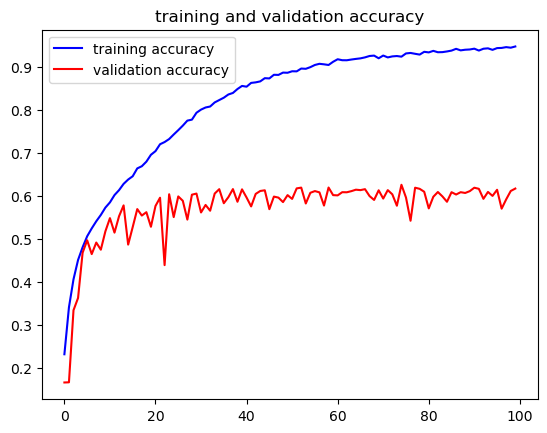

In [53]:
#accuracy
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
epochs=range(len(acc))
plt.plot(epochs,acc,'b',label='training accuracy')
plt.plot(epochs,val_acc,'r',label='validation accuracy')
plt.title('training and validation accuracy')
plt.legend()
plt.show()


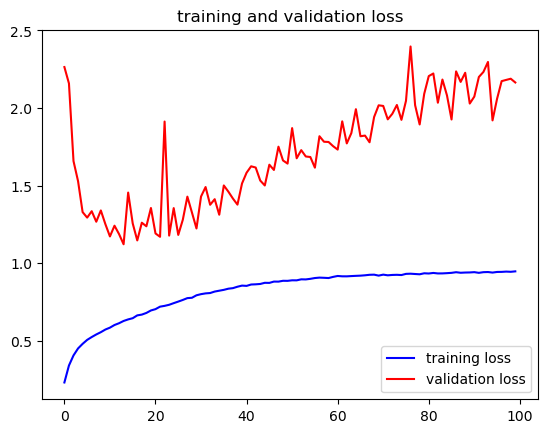

In [54]:
#loss
loss=history.history['loss']
val_acc=history.history['val_loss']
epochs=range(len(loss))
plt.plot(epochs,acc,'b',label='training loss')
plt.plot(epochs,val_acc,'r',label='validation loss')
plt.title('training and validation loss')
plt.legend()
plt.show()

##test with image data

original output:  sad
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
predicted output:  sad


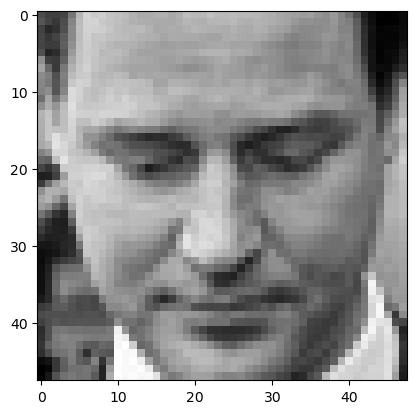

In [59]:
image_index=random.randint(0,len(test))
print("original output: ",test['label'][image_index])
pred=model.predict(x_test[image_index].reshape(1,48,48,1))
prediction_label=le.inverse_transform(pred.argmax(axis=1))[0]
print("predicted output: ",prediction_label)
plt.imshow(x_test[image_index].reshape(48,48),cmap='gray')

In [ ]:
model.save('emotion_model.keras')